In [1]:
from models.exc_based_model import ExcitatoryModel
from pathlib import Path
import joblib
from insilico_stimuli.stimuli import GaborSet, CenterSurround
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


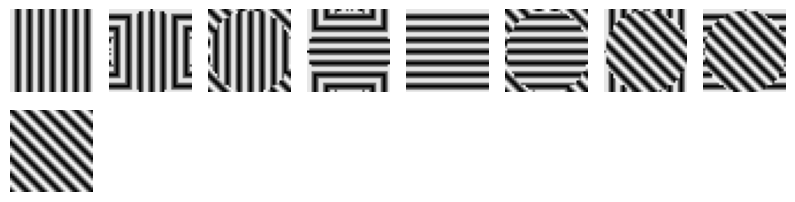

In [2]:
canvas_size = [36, 36]
locations = [[18, 18]]  # center position
sizes_total = [36]  # total size (center + surround)
sizes_center = [0.5]  # portion of radius used for center circle
sizes_surround = [0.5]  # defines the starting portion of radius for surround
contrasts_center = [1.0]  # try 2 center contrasts
contrasts_surround = [1.0]  # surround contrast
orientations_center = [0.0, np.pi / 2, np.pi / 4]  # variable orientation
orientations_surround = [0.0, np.pi / 2, np.pi / 4]  # center only
spatial_frequencies_center = [0.2]  # fixed spatial frequency
phases_center = [np.pi]  # center phases
grey_levels = [0.0]  # fixed grey level
# spatial_frequencies_surround = [0.1, 0.3]  # optional parameter, default: same as spatial_frequencies_center
# phases_surround = [np.pi/4]                # optional parameter, default: same as phases_center

center_surround = CenterSurround(
    canvas_size=canvas_size,
    locations=locations,
    sizes_total=sizes_total,
    sizes_center=sizes_center,
    sizes_surround=sizes_surround,
    contrasts_center=contrasts_center,
    contrasts_surround=contrasts_surround,
    orientations_center=orientations_center,
    orientations_surround=orientations_surround,
    spatial_frequencies_center=spatial_frequencies_center,
    phases_center=phases_center,
    grey_levels=grey_levels,
)

# plot the generated images
plt.figure(figsize=(10, 5))
for i, img in enumerate(center_surround.images()):
    plt.subplot(4, 8, i + 1)
    plt.imshow(img, cmap="gray", vmin=-1, vmax=1)
    plt.axis("off")

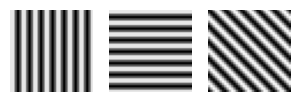

In [3]:
gratings = np.array(
    [
        center_surround.images()[idx]
        for idx in range(len(center_surround.images()))
        if center_surround.params_dict_from_idx(idx)["orientation_center"]
        == center_surround.params_dict_from_idx(idx)["orientation_surround"]
    ]
)
plt.figure(figsize=(10, 5))
for i, img in enumerate(gratings):
    plt.subplot(4, 8, i + 1)
    plt.imshow(img, cmap="gray", vmin=-1, vmax=1)
    plt.axis("off")

In [4]:
data_basepath = Path("/src/project/data/ica/repeat_9_crop_12_comp_40")
x_sigma = 1
I_sigma = 1

print("Loading X_I_models")
X_I_models_path = data_basepath / "layer2_models"
X_I_models = []
for entry in X_I_models_path.iterdir():
    # go through files and load joblib files
    if entry.is_file() and entry.suffix == ".joblib":
        model = joblib.load(entry)
        X_I_models.append(model)

print("Creating hierarchical model")
model = ExcitatoryModel(
    excitatory_stimuli=gratings,
    G_prob=1 / 3,
    X_sigma=x_sigma,
    X_I_models=X_I_models,
    I_sigma=I_sigma,
)

Loading X_I_models
Creating hierarchical model


In [5]:
all_X_RFs_flat = (
    np.array([model.mixing_ for model in X_I_models])
    .transpose(1, 0, 2)
    .reshape(144, -1)
)
print(all_X_RFs_flat.shape)

(144, 360)


(-0.5, 35.5, 35.5, -0.5)

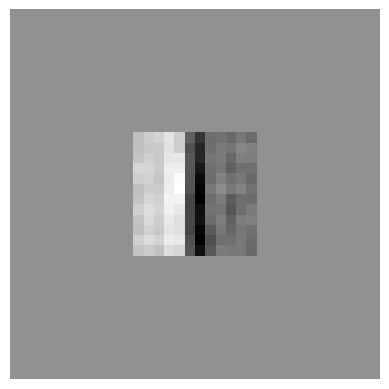

In [6]:
MEI_167 = np.zeros((36, 36))
MEI_167_center = all_X_RFs_flat[:, 167].reshape((12, 12))
MEI_167[12:24, 12:24] = MEI_167_center
plt.imshow(MEI_167, cmap="gray")
plt.axis("off")

In [7]:
l2_norm_167 = np.linalg.norm(MEI_167_center)

In [8]:
l2_norm_167

42.72343989281055

In [9]:
l2_norm_exc = np.linalg.norm(gratings[0])
l2_norm_exc

25.564864675932657

(-0.5, 35.5, 35.5, -0.5)

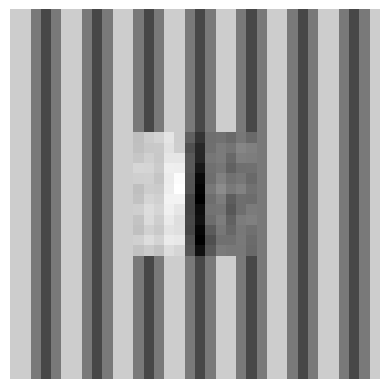

In [10]:
completing_image = gratings[0] * 4
completing_image[12:24, 12:24] = MEI_167_center
plt.imshow(completing_image, cmap="gray")
plt.axis("off")

(-0.5, 35.5, 35.5, -0.5)

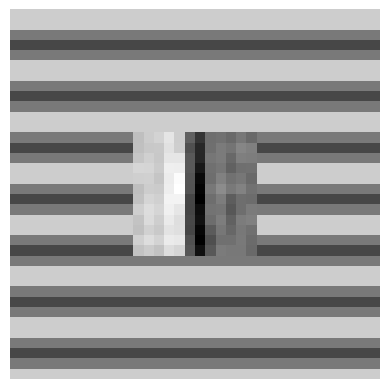

In [11]:
disrupting_image = gratings[1] * 4
disrupting_image[12:24, 12:24] = MEI_167_center
plt.imshow(disrupting_image, cmap="gray")
plt.axis("off")

In [12]:
n_samples = 50

In [13]:
stimuli = [MEI_167, completing_image, disrupting_image]
all_samples = []
for stimulus in stimuli:
    post_samples = model.sample_posterior(
        image=stimulus, n_samples=n_samples, random_seed=42, tune=100, chains=4, cores=4
    )
    all_samples.append(post_samples)

Only 50 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 100 tune and 50 draw iterations (400 + 200 draws total) took 103 seconds.
The number of samples is too small to check convergence reliably.
Only 50 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 100 tune and 50 draw iterations (400 + 200 draws total) took 114 seconds.
The number of samples is too small to check convergence reliably.
Only 50 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 100 tune and 50 draw iterations (400 + 200 draws total) took 217 seconds.
The number of samples is too small to check convergence reliably.


In [14]:
all_x_samples_reshaped = []
for samples in all_samples:
    samples = samples["posterior"]["X"].data.reshape(4 * n_samples, 360)
    all_x_samples_reshaped.append(samples)

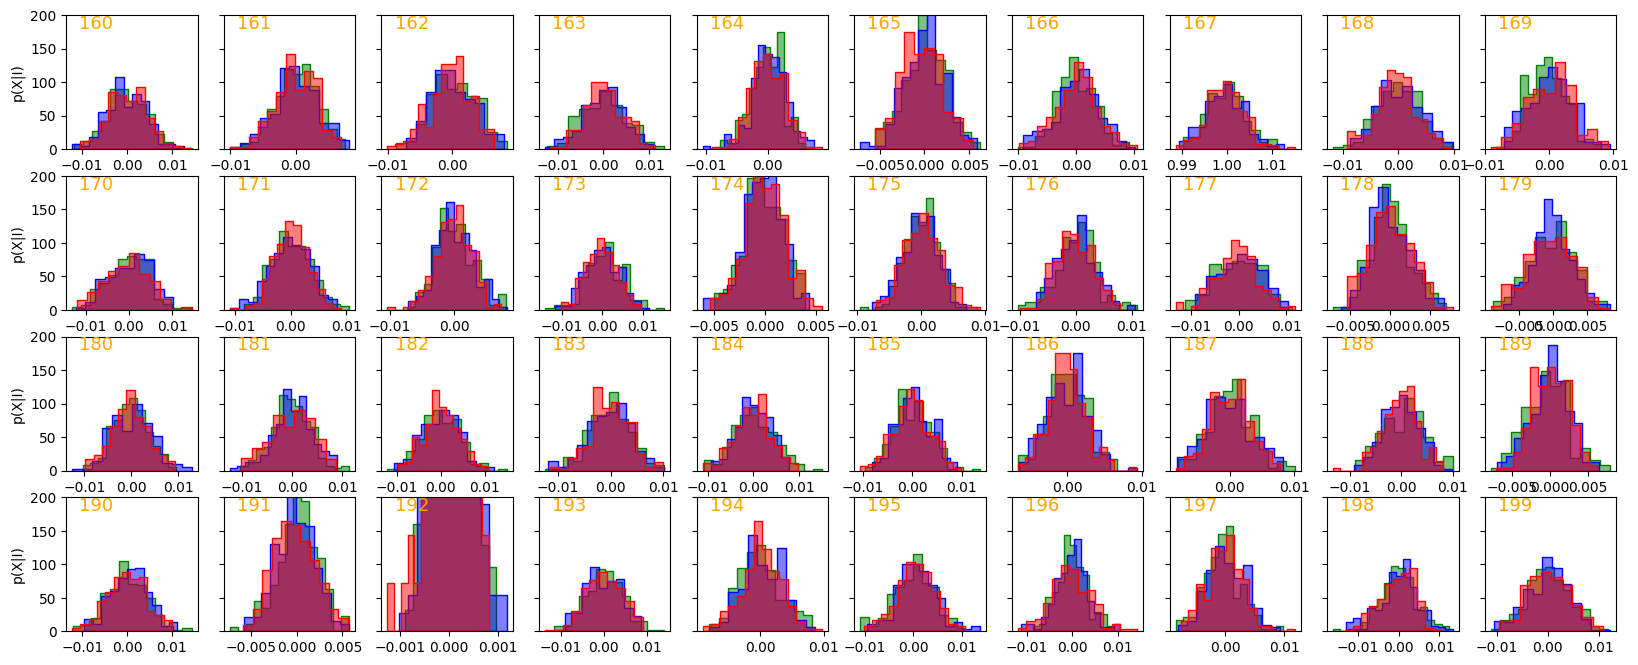

In [15]:
center_offset = 160
fig, axs = plt.subplots(nrows=4, ncols=10, figsize=(2 * 10, 2 * 4), sharey=True)
for i, ax in enumerate(axs.flat):
    neuron_id = i + center_offset
    sns.histplot(
        all_x_samples_reshaped[0][:, neuron_id],
        ax=ax,
        stat="density",
        color="green",
        element="step",
        alpha=0.5,
        label="MEI",
    )
    sns.histplot(
        all_x_samples_reshaped[1][:, neuron_id],
        ax=ax,
        stat="density",
        color="blue",
        element="step",
        alpha=0.5,
        label="completing",
    )
    sns.histplot(
        all_x_samples_reshaped[2][:, neuron_id],
        ax=ax,
        stat="density",
        color="red",
        element="step",
        alpha=0.5,
        label="disrupting",
    )
    # samples_mean = samples.mean(axis=0)
    # ax.axvline(samples_mean[neuron_id], color="red", linestyle="--")
    # ax.text(0.8, 0.9, f"{samples_mean[neuron_id]*1000:.1f}e-3", size=10, ha="center", va="center", transform=ax.transAxes, color='red')
    ax.text(
        0.1,
        0.9,
        str(neuron_id),
        color="orange",
        fontsize=13,
        transform=ax.transAxes,
    )
    ax.set_ylim([0, 200])
    ax.set_ylabel("p(X|I)")

In [16]:
all_samples[0]["posterior"]["G"].data.reshape(4 * n_samples, 3).sum(axis=0)

array([0, 0, 0])

In [17]:
gratings.shape

(3, 36, 36)

In [18]:
all_grating_samples = []
for grating in gratings:
    grating_samples = model.sample_posterior(
        image=grating, n_samples=n_samples, random_seed=42, tune=100, chains=4, cores=4
    )
    all_grating_samples.append(grating_samples)

Only 50 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 100 tune and 50 draw iterations (400 + 200 draws total) took 231 seconds.
The number of samples is too small to check convergence reliably.
Only 50 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 100 tune and 50 draw iterations (400 + 200 draws total) took 223 seconds.
The number of samples is too small to check convergence reliably.
Only 50 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 100 tune and 50 draw iterations (400 + 200 draws total) took 123 seconds.
The number of samples is too small to check convergence reliably.


In [19]:
all_x_grating_samples_reshaped = []
for samples in all_grating_samples:
    samples = samples["posterior"]["X"].data.reshape(4 * n_samples, 360)
    all_x_grating_samples_reshaped.append(samples)

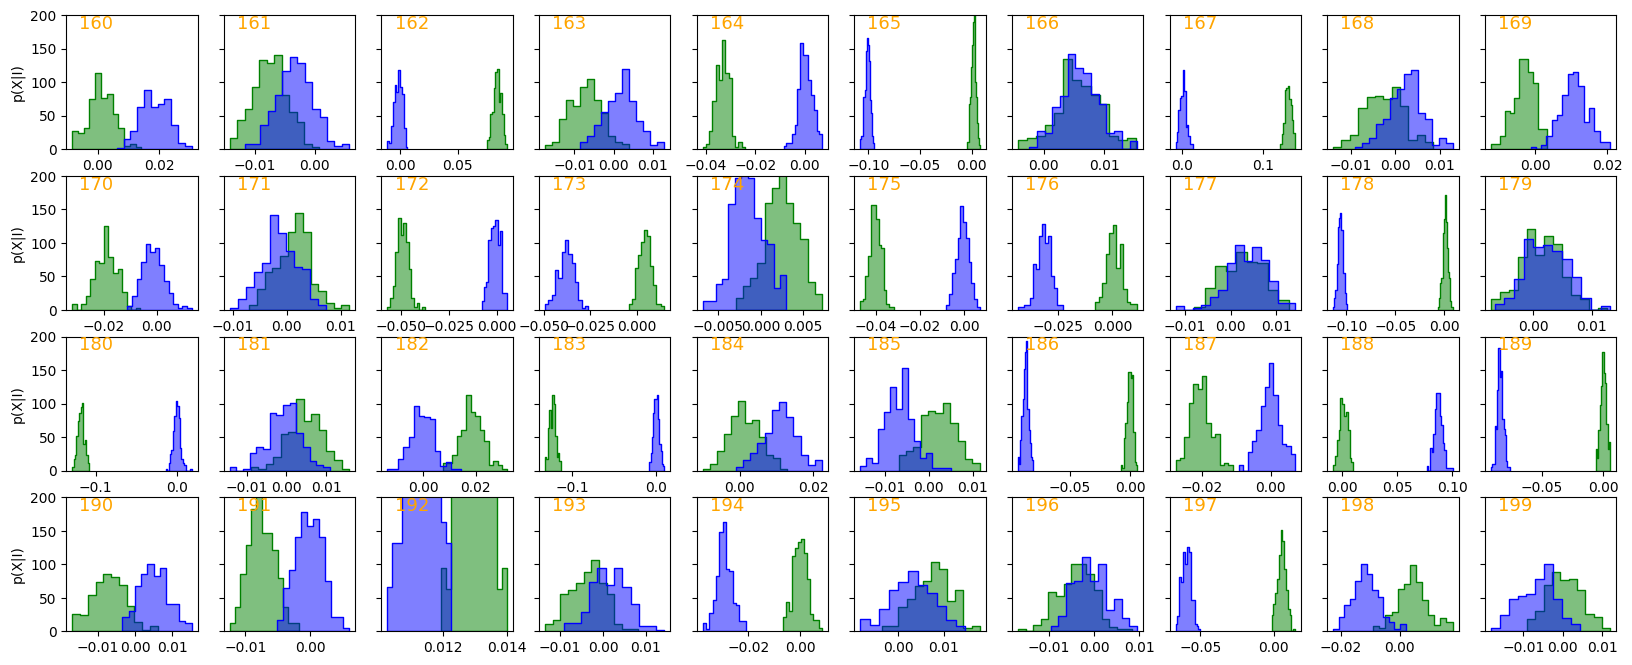

In [20]:
center_offset = 160
fig, axs = plt.subplots(nrows=4, ncols=10, figsize=(2 * 10, 2 * 4), sharey=True)
for i, ax in enumerate(axs.flat):
    neuron_id = i + center_offset
    sns.histplot(
        all_x_grating_samples_reshaped[0][:, neuron_id],
        ax=ax,
        stat="density",
        color="green",
        element="step",
        alpha=0.5,
        label="vertical",
    )
    sns.histplot(
        all_x_grating_samples_reshaped[1][:, neuron_id],
        ax=ax,
        stat="density",
        color="blue",
        element="step",
        alpha=0.5,
        label="horizontal",
    )
    # sns.histplot(
    #     all_x_grating_samples_reshaped[2][:, neuron_id],
    #     ax=ax,
    #     stat="density",
    #     color="red",
    #     element="step",
    #     alpha=0.5,
    #     label="diagonal"
    # )
    # samples_mean = samples.mean(axis=0)
    # ax.axvline(samples_mean[neuron_id], color="red", linestyle="--")
    # ax.text(0.8, 0.9, f"{samples_mean[neuron_id]*1000:.1f}e-3", size=10, ha="center", va="center", transform=ax.transAxes, color='red')
    ax.text(
        0.1,
        0.9,
        str(neuron_id),
        color="orange",
        fontsize=13,
        transform=ax.transAxes,
    )
    ax.set_ylim([0, 200])
    ax.set_ylabel("p(X|I)")

In [21]:
print(
    all_grating_samples[0]["posterior"]["G"].data.reshape(4 * n_samples, 3).sum(axis=0)
)
print(
    all_grating_samples[1]["posterior"]["G"].data.reshape(4 * n_samples, 3).sum(axis=0)
)
print(
    all_grating_samples[2]["posterior"]["G"].data.reshape(4 * n_samples, 3).sum(axis=0)
)

[0 0 0]
[0 0 0]
[0 0 0]
